# A5 CW Solutions: Fitting QNMs
### Joey Wee

- Let's start by examining and plotting the data.dat file.

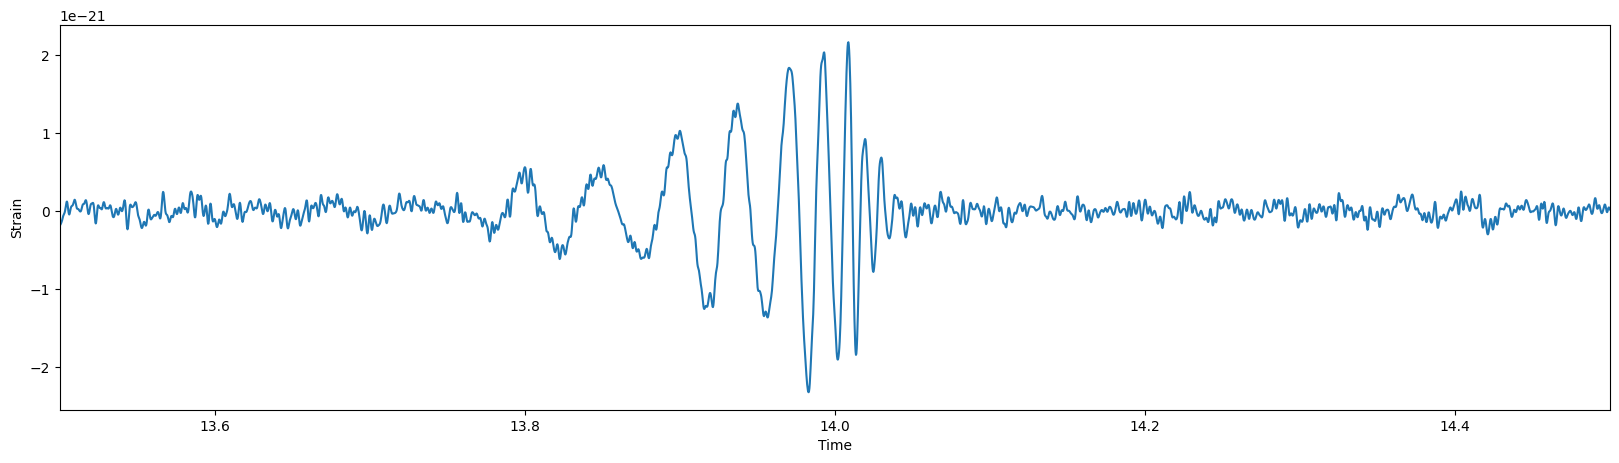

In [582]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('data.dat', skiprows=1)

fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Time")
ax.set_ylabel("Strain")
ax.plot(data[:,0], data[:,1])
ax.set_xlim(13.5,14.5)

t = data[:,0]
strain = data[:,1]


In [583]:
import qnm
qnm.download_data()

Destination path C:\Users\Joey\.qnm\data-0.4.0.tar.bz2 already exists, use overwrite=True to force an overwrite.


- Any black hole can be described by the mass $M$ and the angular momentum $J = \chi M^2$. $\chi \in [0,1[$ 

## Q1: Calculate the dimensionless frequencies
- Consider (l, m, n) = (2, 2, 0) and (3, 3, 0)
- Calculate the dimensionless frequencies.
- Plot the real and imaginary parts of those frequencies.
    - The real part is the oscillatin' part.
    - The imaginary part causes the pertrubation to decay in time.


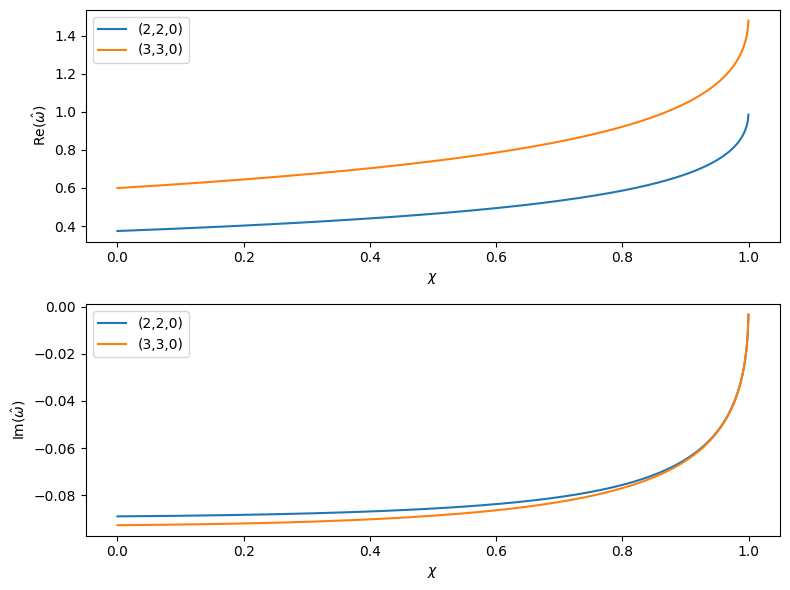

In [584]:
chi_values = np.linspace(0, 0.9999, 1000)

# Storage
omega_220 = []
omega_330 = []

# Get mode objects
mode_220 = qnm.modes_cache(s=-2, l=2, m=2, n=0)
mode_330 = qnm.modes_cache(s=-2, l=3, m=3, n=0)

# Loop over chi values
for chi in chi_values:
    w220, _, _ = mode_220(chi)
    w330, _, _ = mode_330(chi)
    omega_220.append(w220)
    omega_330.append(w330)

# Convert to numpy arrays
omega_220 = np.array(omega_220)
omega_330 = np.array(omega_330)

# Now plot real and imaginary parts separately
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.plot(chi_values, omega_220.real, label='(2,2,0)')
ax1.plot(chi_values, omega_330.real, label='(3,3,0)')
ax1.set_ylabel(r'$\mathrm{Re}(\hat{\omega})$')

ax2.plot(chi_values, omega_220.imag, label='(2,2,0)')
ax2.plot(chi_values, omega_330.imag, label='(3,3,0)')
ax2.set_ylabel(r'$\mathrm{Im}(\hat{\omega})$')

for ax in (ax1, ax2):
    ax.set_xlabel(r'$\chi$')
    ax.legend()

plt.tight_layout()
plt.show()

## Q2: Splitting Data
- Data has off and on-source regimes. How should I split them?
- There is also a time $t_0$ where the ringdown begins. How to identify?
- *Only analyse on-source at $t>t_0$*.

----
- Ideas:
    - Find peaks to find the maxima and minima. The highest can be the start of ringodown. 
    - Moving window. When is variance larger? This can find on-source.
    - Spectrogram to find on source? Can identify region where the signals are clearly different.

#### Spectrogram

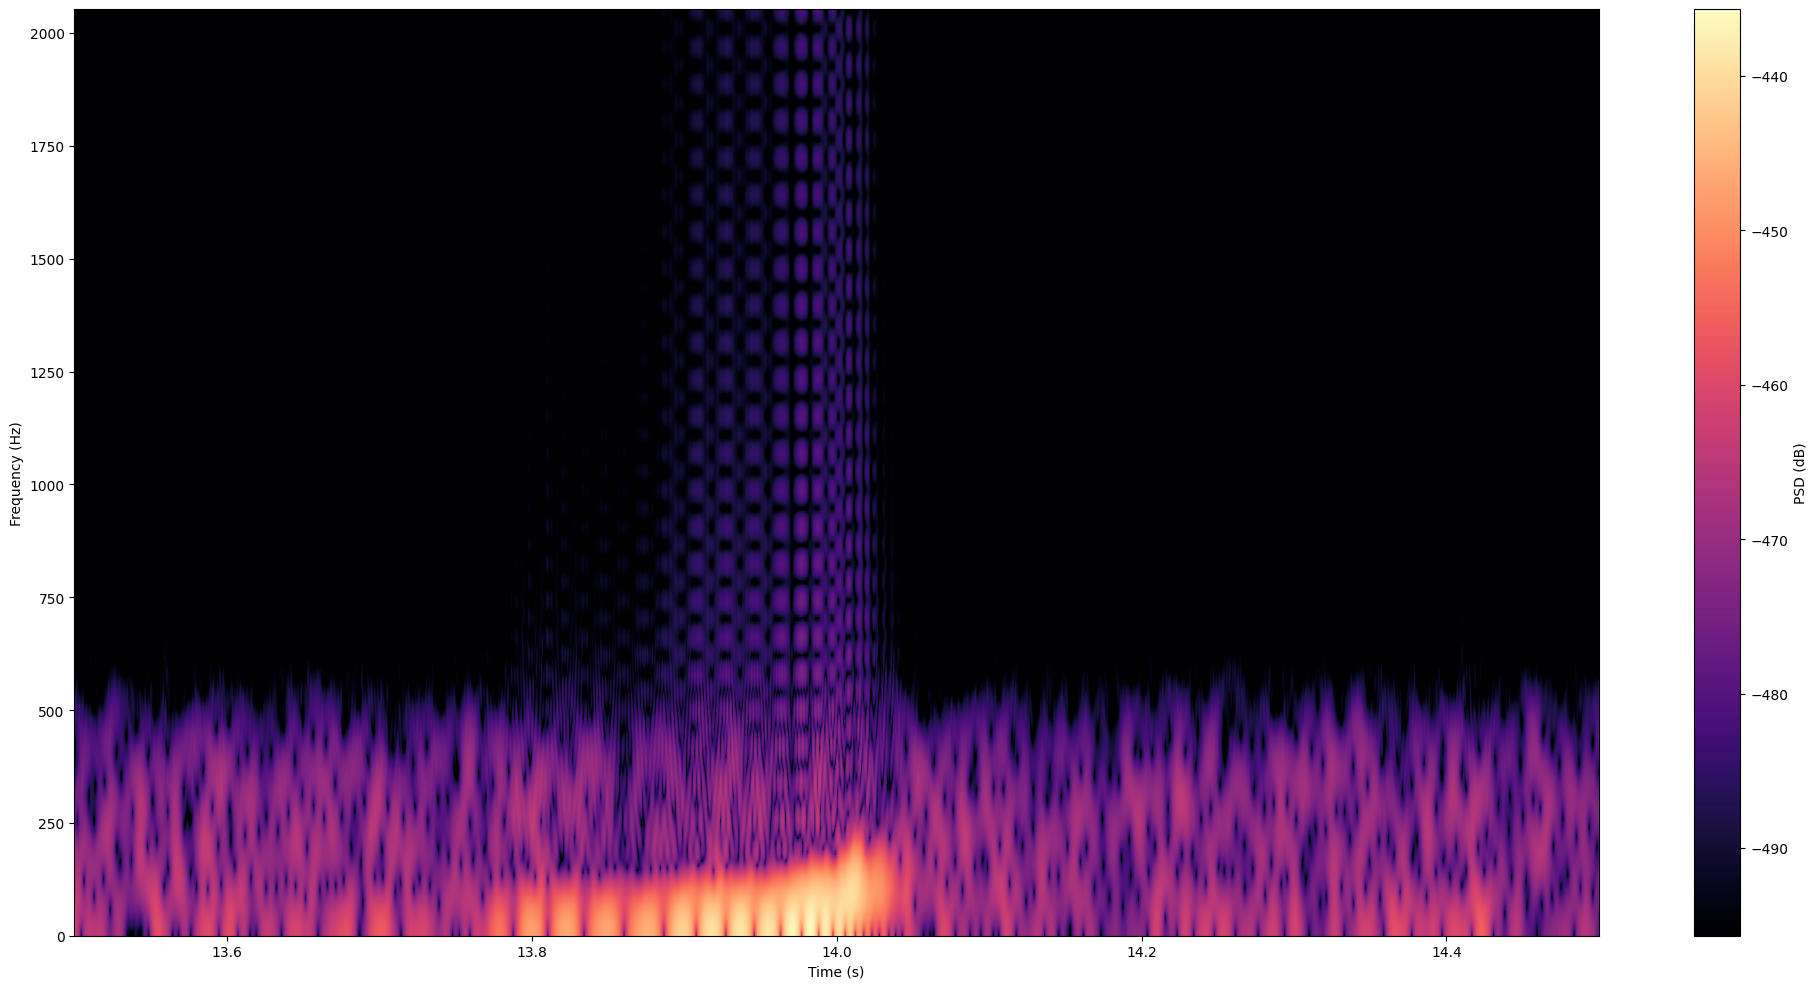

In [585]:
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import gaussian


# 32 seconds of data at 4096 Hz
# Let's spectrogram at 100 Hz
 
T_x = 1/4096 # Time between samples
N = len(t) # Number of samples

# Time indices for the signal
t_x = np.arange(N) * T_x # N time ppoints spanning across N*T_x seconds

# Create windows using Gaussian weighting to prevent frequency artefacts
g_std = 12 # Width of Gaussian window
win  = gaussian(50, std=g_std, sym=True)
SFT = ShortTimeFFT(win, hop=2, fs=1/T_x, mfft=800, scale_to='psd')
Sx2 = SFT.spectrogram(strain) # Magnitude squared "x2"

Sx_dB = 10 * np.log10(np.fmax(Sx2, Sx2.max() * 1e-6))

fig, ax = plt.subplots(figsize= (20,10))
t_lo, t_hi = SFT.extent(N)[:2] # Slightly wider time range because of the windows
ax.set_xlim(13.5,14.5)
im = ax.imshow(Sx_dB, origin='lower', aspect='auto',
               extent=SFT.extent(N), cmap='magma')
ax.set(xlabel='Time (s)', ylabel='Frequency (Hz)')
fig.colorbar(im, label='PSD (dB)')
fig.tight_layout()
plt.show()





- We can see here that, compared to the background, 13.7 to 14.1 is different. We can treat this as out on-signal time. 
- This agrees with the strain vs time plot well.
- We can use a Hilbert transform the signal to get the amplitude term.
- We take the peak of this amplitude to be the start of our ringdown time $t_0$.

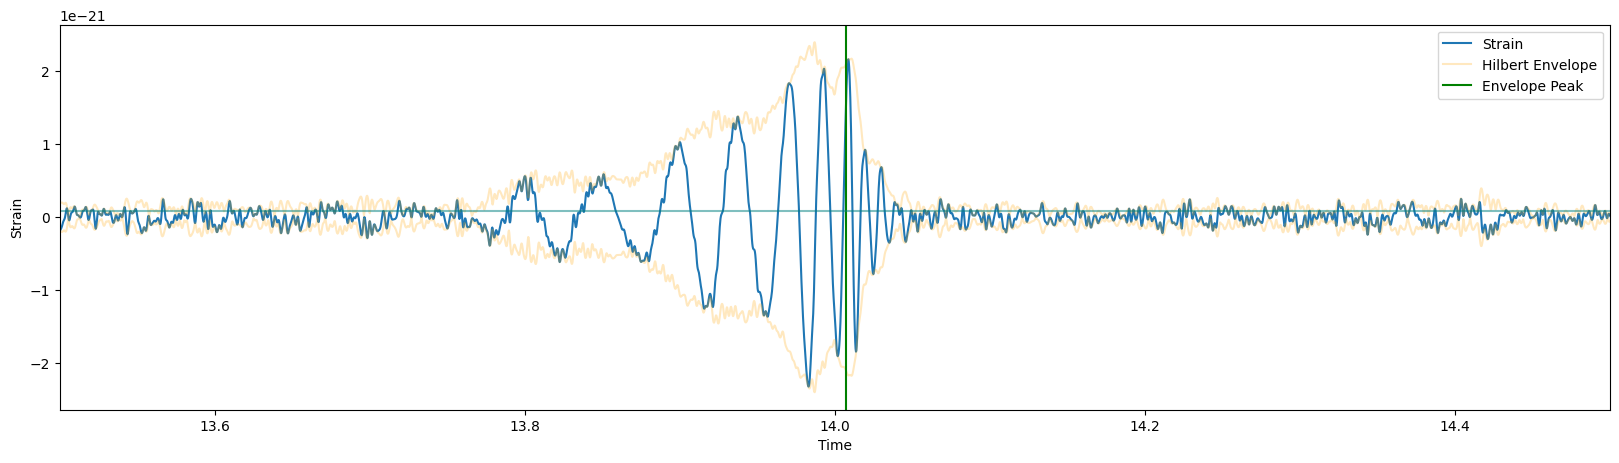

In [586]:
from scipy.signal import hilbert

analytic = hilbert(strain)
envelope = np.abs(analytic)
t0 = t[np.argmax(envelope)]

fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Time")
ax.set_ylabel("Strain")
ax.plot(t, strain, label='Strain')
ax.plot(t, envelope, alpha=0.25, label='Hilbert Envelope', color='orange')
ax.plot(t, -envelope, alpha=0.25, color='orange')
ax.axvline(t0+0.02, color='green', label='Envelope Peak')
ax.axhline(8.32e-23, color='teal', alpha=0.5)
ax.set_xlim(13.5,14.5)
ax.legend()

In [587]:
on_times = (13, 14.5)
t0 = t0+0.02

## Q3: Estimate the $\sigma$
- I think it would be reasonable to use the standard deviation of the off-source data.

In [588]:
on_time_start, on_time_end = on_times
off_strain = strain[(t < on_time_start) | (t > on_time_end)]
off_std = np.std(off_strain)


#------
t_on = t[(t > on_time_start) & (t < on_time_end)]
d_on = strain[(t > on_time_start) & (t < on_time_end)]

t_off_1 = t[(t < on_time_start)]
d_off_1 = strain[(t < on_time_start)]

t_off_2 = t[(t > on_time_end)]
d_off_2 = strain[(t > on_time_end)]

# t_off_1 = t[(t < (on_time_start - 1))]
# d_off_1 = strain[(t < (on_time_start - 1))]

# t_off_2 = t[(t > (on_time_end + 1))]
# d_off_2 = strain[(t > (on_time_end + 1))]

t_ring = t_on[t_on > t0]
d_ring = d_on[t_on > t0]

## Q4: Sample parameters
- Priors:
    - A we dk amplitude so use 5x max ringdown strain as upper bound and 0 as a lower bound with log-uniform.
    - Phi is uniform between 0 and 2 pi.
    - f is log-uniform between 0 and the data frequency.
    - Tau is log-uniform between 0 and the data length.

In [589]:
# import emcee

# def ringdown_model(t, A1, phi1, f1, tau1, A2, phi2, f2, tau2, t0): # this is h(t)
#     h1 = A1 * np.cos(2*np.pi*f1*(t - t0) + phi1) * np.exp(-(t - t0)/tau1)
#     h2 = A2 * np.cos(2*np.pi*f2*(t - t0) + phi2) * np.exp(-(t - t0)/tau2)
#     return h1 + h2

# def lnPi(theta):
#     A1, phi1, f1, tau1, A2, phi2, f2, tau2 = theta

#     A_min, A_max = 0, 1e-20
#     phi_min, phi_max = -np.pi, np.pi
#     f_min, f_max = 0, 4096
#     tau_min, tau_max = 0, 32
    
#     # log-uniform on amplitudes
#     if not (A_min < A1 < A_max and A_min < A2 < A_max):
#         return -np.inf
    
#     # uniform on phases
#     if not (phi_min < phi1 < phi_max and phi_min < phi2 < phi_max):
#         return -np.inf
    
#     # log-uniform on frequencies (Hz) - adjust range to your signal
#     if not (f_min < f1 < f_max and f_min < f2 < f_max):
#         return -np.inf
    
#     # log-uniform on damping times (s)
#     if not (tau_min < tau1 < tau_max and tau_min < tau2 < tau_max):
#         return -np.inf
    
#     # log-uniform prior contribution for amplitudes
#     lp = -np.log(A1) - np.log(A2)
#     lp += -np.log(f1) - np.log(f2)
#     lp += -np.log(tau1) - np.log(tau2)
#     return lp

# def lnL(theta, t, data, std=off_std):
#     A1, phi1, f1, tau1, A2, phi2, f2, tau2 = theta
#     h = ringdown_model(t, A1, phi1, f1, tau1, A2, phi2, f2, tau2, t0)
#     return -0.5 * np.sum((data - h)**2 / std**2)

# def lnPost(theta, t, d, sigma):
#     lp = lnPi(theta)
#     if not np.isfinite(lp):
#         return -np.inf
#     return lp + lnL(theta, t, d, sigma)

# # Run Emcee
# ndim = 8
# nwalkers = 64  # must be > 2*ndim, even number

# # Define the center of your initial ball
# # (A1,    phi1, f1,    tau1,  A2,    phi2, f2,    tau2)
# p0_guess = np.array([1e-22, 0.0, 150.0, 0.01, 1e-22, 0.0, 250.0, 0.01])

# # Define spread for each parameter individually
# p0_spread = np.array([1e-23, 0.1, 10.0, 0.001, 1e-23, 0.1, 10.0, 0.001])

# rng = np.random.default_rng(1701)
# p0 = p0_guess + p0_spread * rng.standard_normal((nwalkers, ndim))

# sampler = emcee.EnsembleSampler(
#     nwalkers, ndim, lnPost,
#     args=(t_on, d_on, off_std)  # your on-source data after t0
# )

In [590]:
# state = sampler.run_mcmc(p0, 50000, progress=True)

In [591]:
# param_names = ['A1', 'phi1', 'f1', 'tau1', 'A2', 'phi2', 'f2', 'tau2']
# fig, axes = plt.subplots(ndim, figsize=(10, 3.5 * ndim), sharex=True)

# chain = sampler.get_chain() # chain shape is (nwalkers, nsteps, ndim)

# for i, ax in enumerate(axes):
#     ax.plot(chain[:, :, i], alpha=0.3, lw=0.5)   # all walkers
#     ax.set_ylabel(param_names[i])

# axes[-1].set_xlabel("Step")
# axes[0].legend()
# plt.tight_layout()
# plt.show()

- Let's discard the first 20k steps.

In [592]:
# burn_in = 20000
# thin = 100

# flat_samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)
# print("Flat samples shape:", flat_samples.shape)  # (n_samples, ndim)

In [593]:
# import corner

# labels = [r"$A_1$", r"$\phi_1$", r"$f_1$", r"$\tau_1$",
#           r"$A_2$", r"$\phi_2$", r"$f_2$", r"$\tau_2$"]

# fig = corner.corner(
#     flat_samples,
#     labels=labels,
#     quantiles=[0.16, 0.5, 0.84],  # 1-sigma credible intervals
#     show_titles=True,
#     title_fmt=".2e",
# )

- This is nasty let's use dynesty instead.

In [594]:
def lnL(theta):
    A1, phi1, f1, tau1, A2, phi2, f2, tau2 = theta
    t = t_ring
    model = (A1 * np.cos(2*np.pi*f1*(t - t0) + phi1) * np.exp(-(t - t0)/tau1) +
             A2 * np.cos(2*np.pi*f2*(t - t0) + phi2) * np.exp(-(t - t0)/tau2))
    residuals = d_ring - model  # d is your on-source data, t > t0
    return -0.5 * np.sum(residuals**2 / off_std**2)

def prior_transform(u):
    A1_u, phi1_u, f1_u, tau1_u, A2_u, phi2_u, f2_u, tau2_u = u

    # log-uniform on amplitudes 
    A_min, A_max = 1e-25, 1e-19
    A1   = A_min * (A_max / A_min) ** A1_u
    A2   = A_min * (A_max / A_min) ** A2_u

    # uniform on phases [-pi, pi]
    phi1 = -np.pi + phi1_u * 2 * np.pi
    phi2 = -np.pi + phi2_u * 2 * np.pi

    # log-uniform on frequencies 
    f_min, f_max = 20.0, 4096.0
    f1   = f_min * (f_max / f_min) ** f1_u
    f2   = f_min * (f_max / f_min) ** f2_u

    # log-uniform on damping times 
    tau_min, tau_max = 1e-4, 1e-1
    tau1 = tau_min * (tau_max / tau_min) ** tau1_u
    tau2 = tau_min * (tau_max / tau_min) ** tau2_u

    return [A1, phi1, f1, tau1, A2, phi2, f2, tau2]

In [595]:
import dynesty

sampler = dynesty.DynamicNestedSampler(
    lnL,
    prior_transform,
    ndim=8,
    bound='multi',    # multiellipsoid bounding (good default)
    sample='rwalk'    # random walk sampling
)

sampler.run_nested(print_progress=True)

30286it [01:43, 292.71it/s, batch: 4 | bound: 6 | nc: 1 | ncall: 788751 | eff(%):  3.775 | loglstar: -1149.791 < -1142.485 < -1144.430 | logz: -1184.017 +/-  0.214 | stop:  0.889]       


In [596]:
from dynesty import utils as dyfunc

results = sampler.results

# Resample to equal weights (important — dynesty samples are not equal weight)
weights = np.exp(results.logwt - results.logz[-1])
samples = dyfunc.resample_equal(results.samples, weights)

# samples has shape (N, 8)
# columns match your parameter order: A1, phi1, f1, tau1, A2, phi2, f2, tau2
A1, phi1, f1, tau1 = samples[:,0], samples[:,1], samples[:,2], samples[:,3]
A2, phi2, f2, tau2 = samples[:,4], samples[:,5], samples[:,6], samples[:,7]

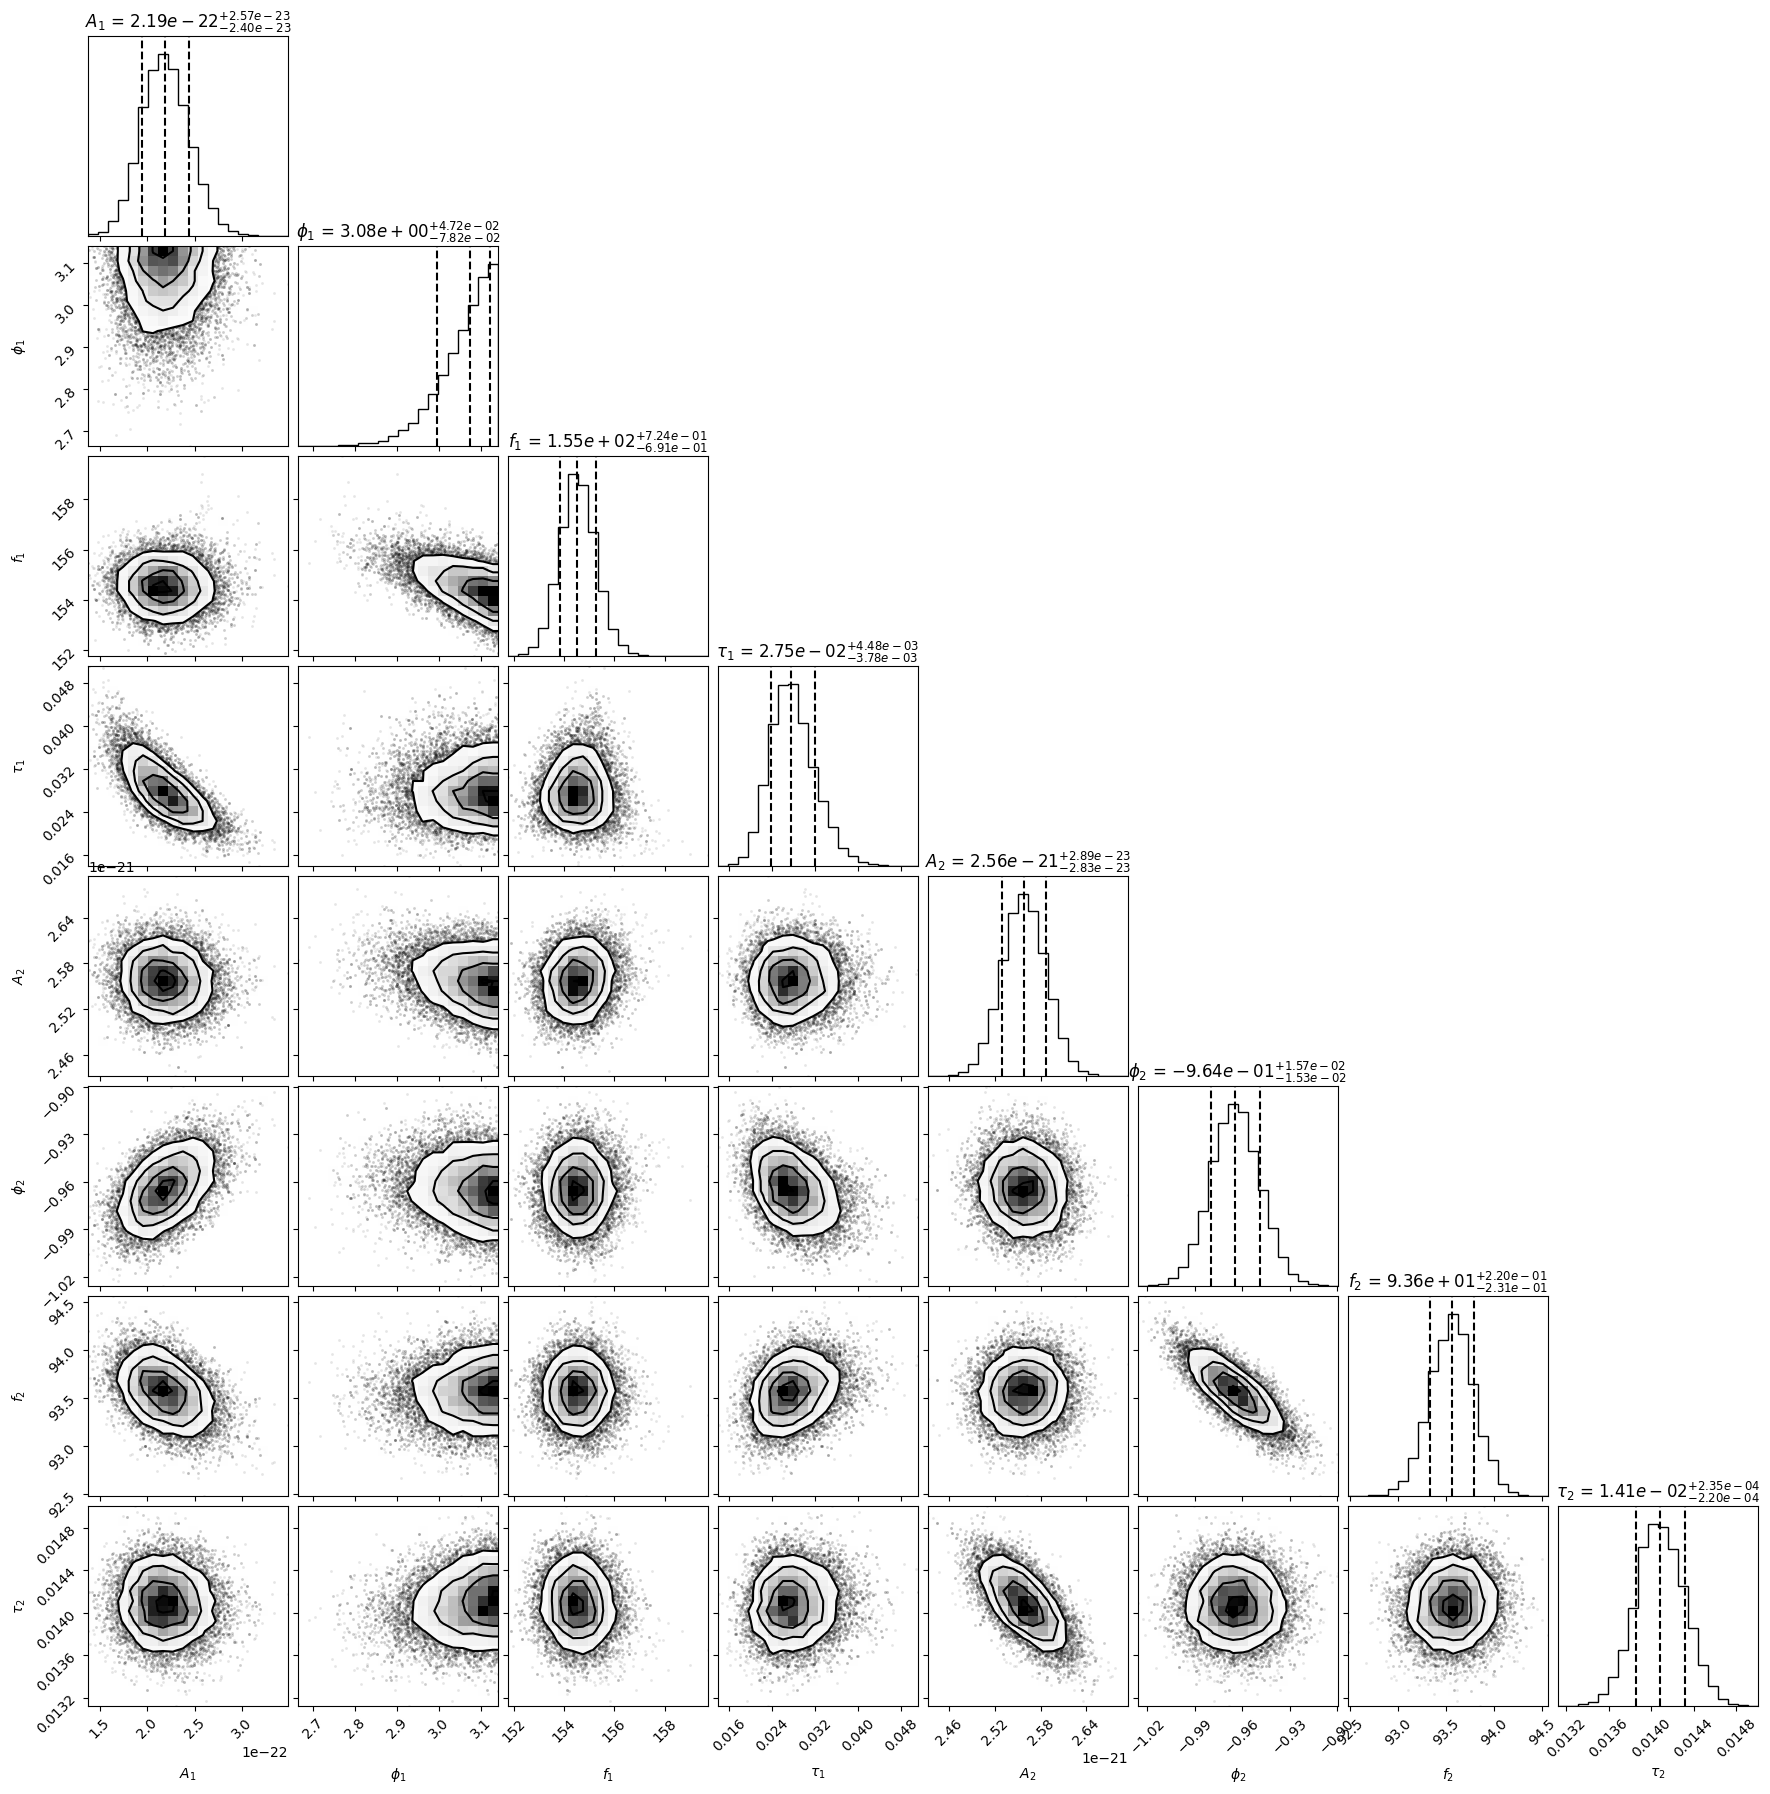

In [597]:
import corner

labels = [r"$A_1$", r"$\phi_1$", r"$f_1$", r"$\tau_1$",
          r"$A_2$", r"$\phi_2$", r"$f_2$", r"$\tau_2$"]

fig = corner.corner(
    samples,
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],  # 1-sigma credible intervals
    show_titles=True,
    title_fmt=".2e",
)

## Q5: Off-source PSD
- The problem is that the concatenation of the two off-source sections would lead to signal bleed.
- I will take a PSD for each and then average them.

In [598]:
from scipy.signal import welch

fs = 4096
f_1, PSD_1 = welch(d_off_1, fs=fs, nperseg=256, noverlap=128, window='hann')
f_2, PSD_2 = welch(d_off_2, fs=fs, nperseg=256, noverlap=128, window='hann')
# f = frequency array, PSD = power spectral density
PSD_mean = np.mean([PSD_1, PSD_2], axis=0)

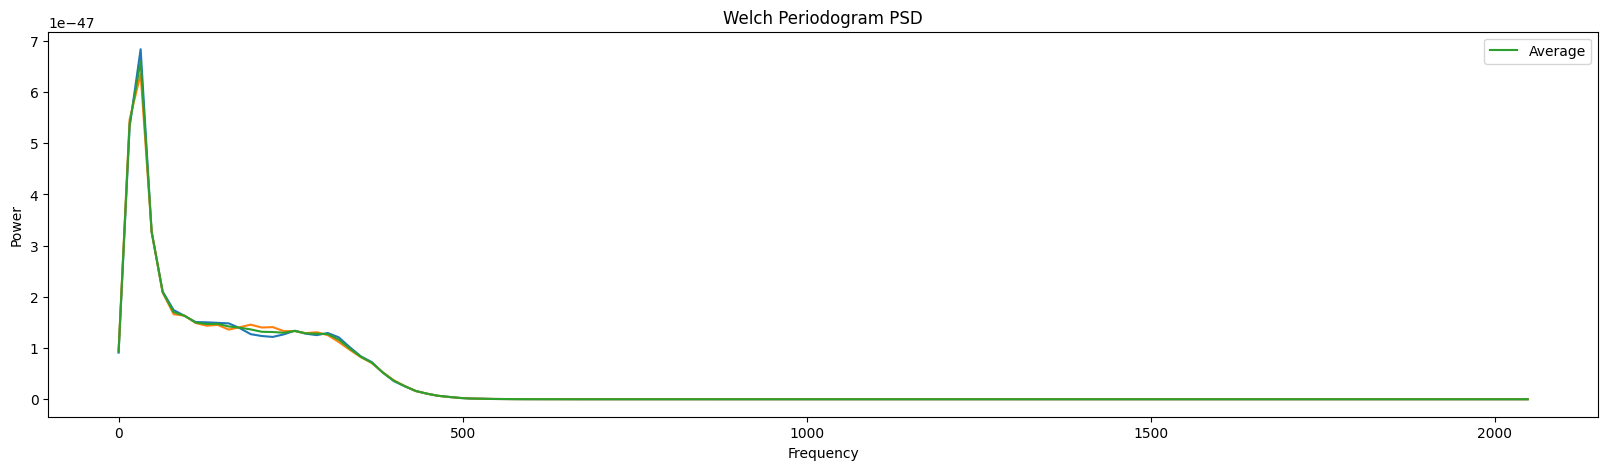

In [599]:
fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Frequency")
ax.set_ylabel("Power")
ax.plot(f_1, PSD_1)
ax.plot(f_2, PSD_2)
ax.plot(f_1, PSD_mean, label='Average')
ax.set_title("Welch Periodogram PSD")
ax.legend()



- Let's examine the instrument noise PSD.

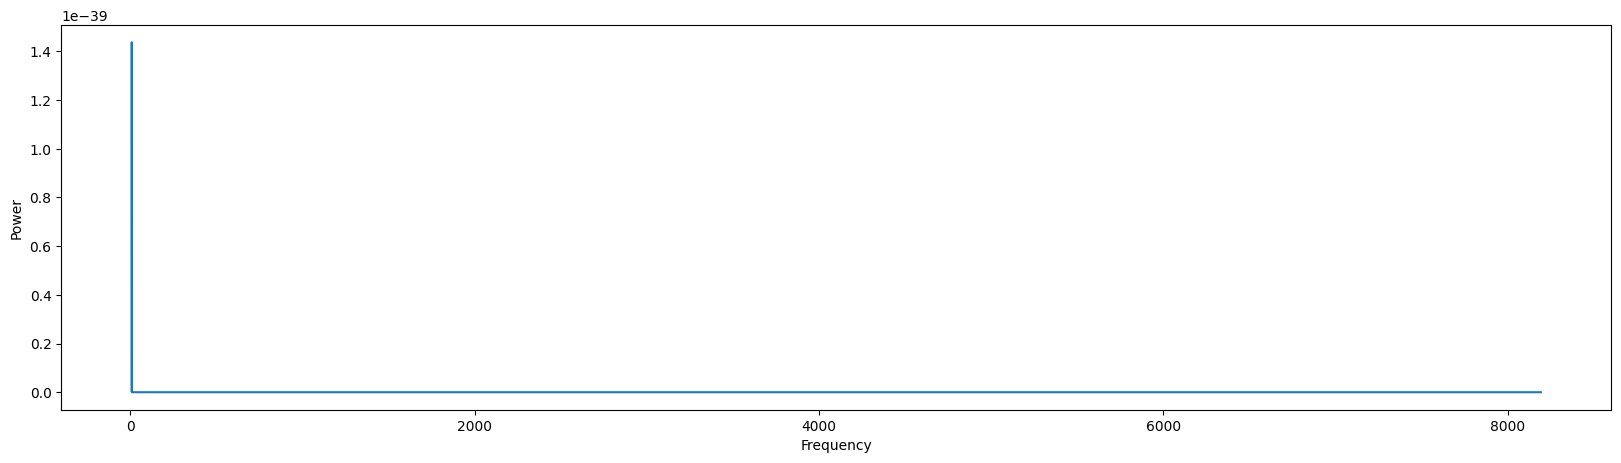

In [600]:
instrument_PSD = np.loadtxt('psd.dat', skiprows=1)
fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Frequency")
ax.set_ylabel("Power")
ax.plot(instrument_PSD[:,0], instrument_PSD[:,1])


- These should be estimates of the same thing.
- Rescale them to plot together.

(0.0, 1000.0)

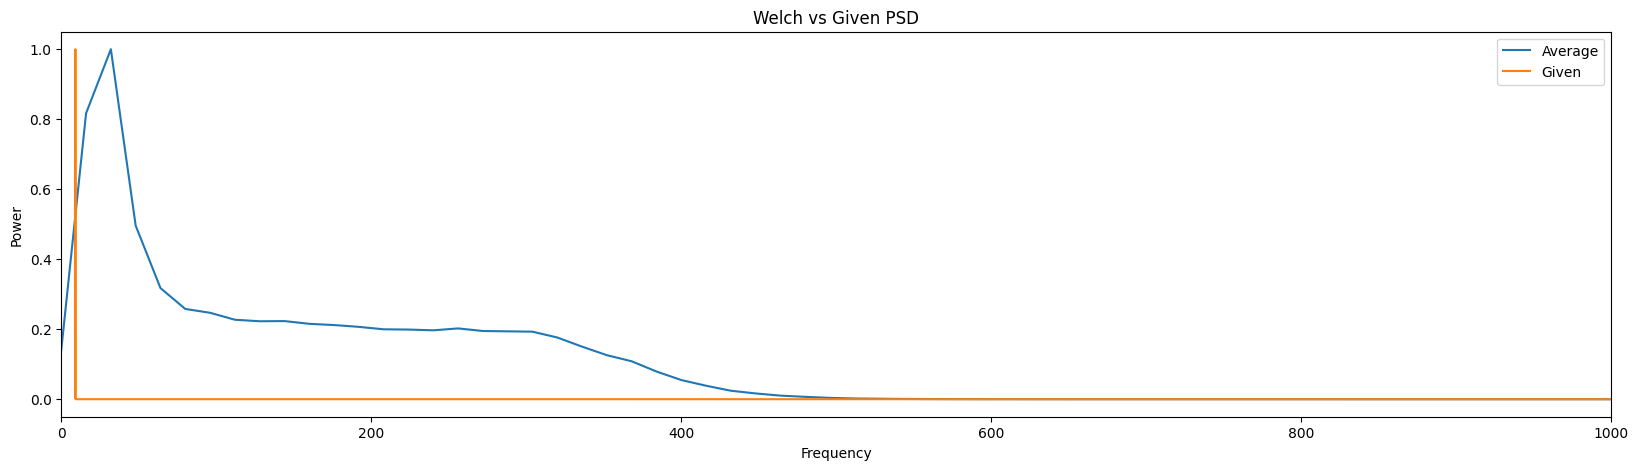

In [601]:
fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Frequency")
ax.set_ylabel("Power")

PSD_mean_rescaled = PSD_mean / max(PSD_mean)
PSD_instrument_rescaled = instrument_PSD[:,1] / max(instrument_PSD[:,1])

ax.plot(f_1, PSD_mean_rescaled, label='Average')
ax.plot(instrument_PSD[:,0], PSD_instrument_rescaled, label="Given")
ax.set_title("Welch vs Given PSD")
ax.legend()
ax.set_xlim(0,1000)


- White noise is a flat spectrum across the frequencies. This is not a constant and has a signifcant noise peak at the low frequencies.
- The low freq spike coul be a function of the detector physics.
- We see the spike at low freq from the true PSD. This, when passed through a bandpass, would smear out that spike as we see.

## Q6: Calculate TDACF 
- If the white noise likelihood holds, the TDACF should be concentrates at 0 (subsequent points are uncorrelated).
- ACF and PSD are FFT pair.

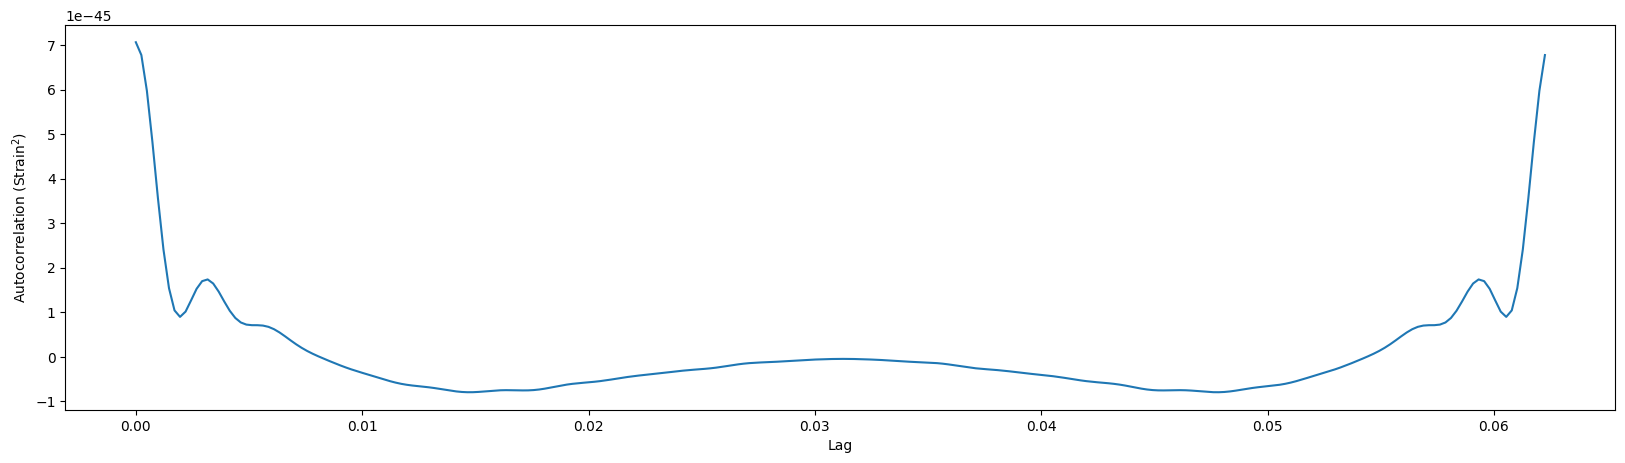

In [602]:
df = f_1[1] - f_1[0]  # sampling interval
N = 2 * (len(PSD_mean) - 1)

N_data = len(PSD_1) + len(PSD_2)# Len of the data
c95 = 1.96 / np.sqrt(N_data)

C = np.fft.irfft(PSD_mean) * df * N / 2   # units: strain²
tau = np.arange(N) * (1 / (N * df))  # lag axis in seconds


fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation (Strain$^2$)")
ax.plot(tau, C)

- This has two lobes because the IRFFT calculates positive and negative lags cyclically.
- Let's plot the first half.

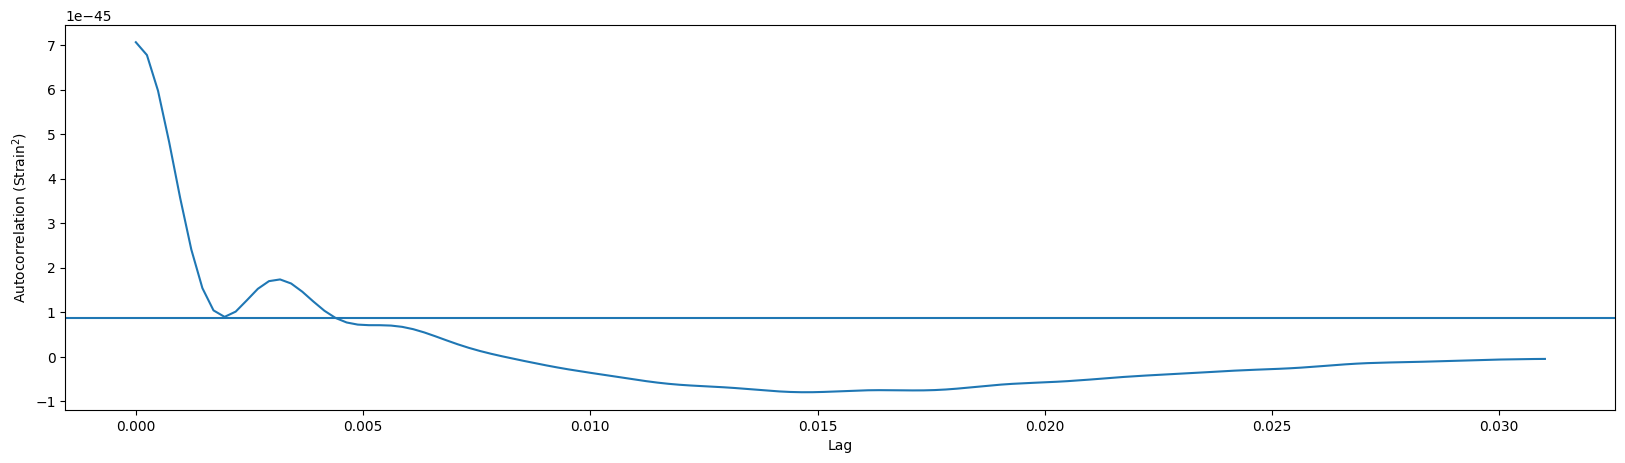

In [603]:
fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation (Strain$^2$)")

scaled_c95 =c95 * C[0]

N = len(tau)
ax.plot(tau[:N//2], C[:N//2])
ax.axhline(scaled_c95, label='95% noise threshold')

- Even though the PSD did not look constant like white noise should, the ACF is still heavily centred around zero, as we would expect from white noise.
- There is a secondary peak above the 95% noise threshold which we can attribute to the non-WN behaviour of the detector but I think white noise is not an entirely unreasonable approximation here.
---
- There is a peak that sits above the noise that is above the 95% confidence for noise so there is probably some other effect in the data.
- The tau = 0 lag is dominant though so I think the white noise kernel is still applicable.

In [604]:
tau[0], C[0]

(np.float64(0.0), np.float64(7.063079648154083e-45))

## Q7: Relating off_std to the ACF


In [605]:
rel = (C[0] - (off_std ** 2)) / (off_std ** 2)
print(f'Relative difference between variance and ACF at 0 lag is {rel:.2f}%')


Relative difference between variance and ACF at 0 lag is 0.02%


- This is pretty close.
- We would expace these values to be the same because of the autocorrelation definition $$R(\tau) = \left\langle x(t) \cdot x(t+\tau) \right\rangle_t$$.
- At tau = 0, we just expect the variance.
- This is a good check of that Wiener-Kinchin business.

## Q8: GR and Kerr Metric Consistency Test
- Describe how.
- Perform it using this signal.

- Under the no-hair theorem, a black hole is fully characterised by $M$ and $\chi$.
- Each complex frequency $\omega_\alpha(M, \chi) = \frac{\hat\omega_\alpha(\chi)}{M}$
- $\hat\omega_\alpha(\chi)$ is fixed by GR.
- Every $\alpha$-mode is a function of the same two parameters.
- We have fit two modes from which we have extracted values of $f_\alpha = \frac{1}{2\pi} (\omega_\alpha + \frac{i}{\tau_\alpha})$ and $\tau_\alpha$.
- These values can be used to solve for $M$ and $\chi$.
- If GR is correct, these should line up (unless there is some deviation from the Kerr black hole ie exotic objects).

In [606]:
# 16th, 50th (median), 84th percentiles for each parameter
lo, med, hi = np.percentile(samples, [16, 50, 84], axis=0)

# for i, label in enumerate(labels):
#     lower_err = med[i] - lo[i]
#     upper_err = hi[i] - med[i]
#     print(f"{label}: {med[i]:.3e} +{upper_err:.3e} / -{lower_err:.3e}")

f1_med = med[2]
f1_lo, f1_hi = lo[2], hi[2]

f2_med = med[6]
f2_lo, f2_hi = lo[6], hi[6]

tau1_med = med[3]
tau1_lo, tau1_hi = lo[3], hi[3]

tau2_med = med[7]
tau2_lo, tau2_hi = lo[7], hi[7]

In [607]:
print(f"f1_med = {f1_med:.1f} Hz")
print(f"f2_med = {f2_med:.1f} Hz")

# 220 mode has the lower frequency = f2

f1_med = 154.5 Hz
f2_med = 93.6 Hz


In [608]:
# 220 mode is always lower frequency than 330 — swap if needed
if f1_med > f2_med:
    f1_med, f2_med = f2_med, f1_med
    f1_lo,  f2_lo  = f2_lo,  f1_lo
    f1_hi,  f2_hi  = f2_hi,  f1_hi
    tau1_med, tau2_med = tau2_med, tau1_med
    tau1_lo,  tau2_lo  = tau2_lo,  tau1_lo
    tau1_hi,  tau2_hi  = tau2_hi,  tau1_hi
    print("Swapped: f1 ↔ f2, tau1 ↔ tau2")

print(f"220 mode: f = {f1_med:.1f} Hz,  tau = {tau1_med:.4f} s")
print(f"330 mode: f = {f2_med:.1f} Hz,  tau = {tau2_med:.4f} s")

Swapped: f1 ↔ f2, tau1 ↔ tau2
220 mode: f = 93.6 Hz,  tau = 0.0141 s
330 mode: f = 154.5 Hz,  tau = 0.0275 s


In [609]:
omega_220_ratio = omega_220.real / np.abs(omega_220.imag)

target_220 = 2 * np.pi * f1_med * tau1_med
lo_220 = 2 * np.pi * f1_lo * tau1_lo
hi_220 = 2 * np.pi * f1_hi * tau1_hi

chi_med_220 = np.interp(target_220, omega_220_ratio, chi_values)
chi_lo_220  = np.interp(lo_220, omega_220_ratio, chi_values)
chi_hi_220  = np.interp(hi_220, omega_220_ratio, chi_values)

chi_lo_220, chi_med_220, chi_hi_220

(np.float64(0.822122564239233),
 np.float64(0.8298424674272147),
 np.float64(0.8374656480425792))

In [610]:
omega_330_ratio = omega_330.real / np.abs(omega_330.imag)

target_330 = 2 * np.pi * f2_med * tau2_med
lo_330 = 2 * np.pi * f2_lo * tau2_lo
hi_330 = 2 * np.pi * f2_hi * tau2_hi

chi_med_330 = np.interp(target_330, omega_330_ratio, chi_values)
chi_lo_330  = np.interp(lo_330, omega_330_ratio, chi_values)
chi_hi_330  = np.interp(hi_330, omega_330_ratio, chi_values)

chi_lo_330, chi_med_330, chi_hi_330

(np.float64(0.9566376528774772),
 np.float64(0.9691271156167138),
 np.float64(0.9780569915419827))

In [611]:
from prettytable import PrettyTable

table = PrettyTable()
table.field_names = ["Mode", "χ (16th)", "χ (median)", "χ (84th)"]
table.add_row(["(2,2,0)", f"{chi_lo_220:.4f}", f"{chi_med_220:.4f}", f"{chi_hi_220:.4f}"])
table.add_row(["(3,3,0)", f"{chi_lo_330:.4f}", f"{chi_med_330:.4f}", f"{chi_hi_330:.4f}"])
print(table)

+---------+----------+------------+----------+
|   Mode  | χ (16th) | χ (median) | χ (84th) |
+---------+----------+------------+----------+
| (2,2,0) |  0.8221  |   0.8298   |  0.8375  |
| (3,3,0) |  0.9566  |   0.9691   |  0.9781  |
+---------+----------+------------+----------+


- These are within uncertainty. Very good.
- Now to calculate M.

In [612]:
def convert_to_Msun(Mseconds):
    return Mseconds * 2.03e5

In [613]:
# Calculate Masses for 220 (uses f1)
omega_hat_med_220, _, _ = mode_220(chi_med_220)
omega_hat_lo_220, _, _  = mode_220(chi_lo_220)
omega_hat_hi_220, _, _  = mode_220(chi_hi_220)

M_med_220 = omega_hat_med_220.real / (2 * np.pi * f1_med)
M_lo_220  = omega_hat_lo_220.real  / (2 * np.pi * f1_hi)
M_hi_220  = omega_hat_hi_220.real  / (2 * np.pi * f1_lo)

M_med_220 = convert_to_Msun(M_med_220)
M_lo_220  = convert_to_Msun(M_lo_220)
M_hi_220  = convert_to_Msun(M_hi_220)

In [614]:
# Calculate Masses for 330 (uses f2)
omega_hat_med_330, _, _ = mode_330(chi_med_330)
omega_hat_lo_330, _, _  = mode_330(chi_lo_330)
omega_hat_hi_330, _, _  = mode_330(chi_hi_330)

M_med_330 = omega_hat_med_330.real / (2 * np.pi * f2_med)
M_lo_330  = omega_hat_lo_330.real  / (2 * np.pi * f2_hi)
M_hi_330  = omega_hat_hi_330.real  / (2 * np.pi * f2_lo)

M_med_330 = convert_to_Msun(M_med_330)
M_lo_330  = convert_to_Msun(M_lo_330)
M_hi_330  = convert_to_Msun(M_hi_330)

In [615]:
table = PrettyTable()
table.field_names = ["Mode", "M_low", "M_med", "M_high"]
table.add_row(["(2,2,0)", f"{M_lo_220:.2f}", f"{M_med_220:.2f}", f"{M_hi_220:.2f}"])
table.add_row(["(3,3,0)", f"{M_lo_330:.2f}", f"{M_med_330:.2f}", f"{M_hi_330:.2f}"])
print(table)

+---------+--------+--------+--------+
|   Mode  | M_low  | M_med  | M_high |
+---------+--------+--------+--------+
| (2,2,0) | 207.08 | 209.52 | 212.04 |
| (3,3,0) | 243.33 | 253.41 | 262.63 |
+---------+--------+--------+--------+


<ErrorbarContainer object of 3 artists>

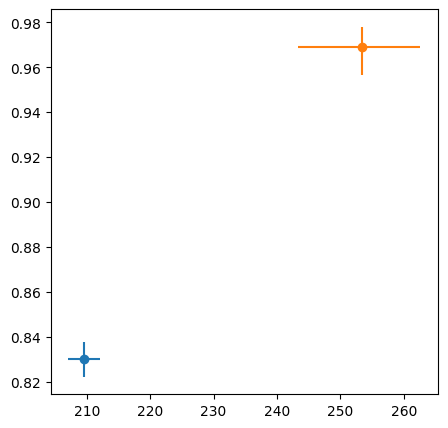

In [616]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.errorbar(M_med_220, chi_med_220,
            xerr=[[M_med_220 - M_lo_220], [M_hi_220 - M_med_220]],
            yerr=[[chi_med_220 - chi_lo_220], [chi_hi_220 - chi_med_220]],
            marker='o')

ax.errorbar(M_med_330, chi_med_330,
            xerr=[[M_med_330 - M_lo_330], [M_hi_330 - M_med_330]],
            yerr=[[chi_med_330 - chi_lo_330], [chi_hi_330 - chi_med_330]],
            marker='o')

# ax.errorbar(M_med_220, chi_med_220, xerr=[M_lo_220-M_med_220,M_hi_220-M_med_220], yerr=[chi_lo_220-chi_med_220,chi_hi_220-chi_med_220], marker='o')
# ax.scatter(M_med_330, chi_med_330, xerr=[,], yerr=[,], s=100, marker='o')

- Let's produce a nice plot.

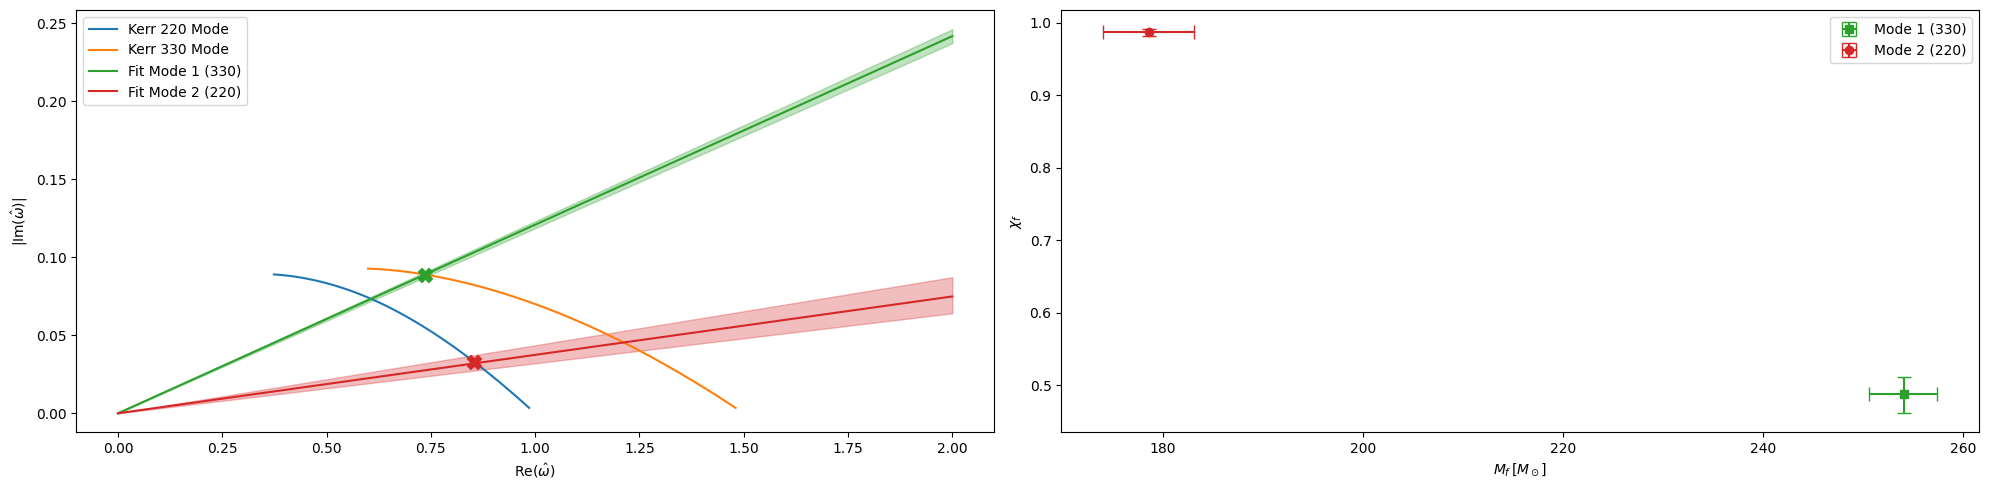

In [617]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

ax[0].set_xlabel(r"$\mathrm{Re}(\hat{\omega})$")
ax[0].set_ylabel(r"$|\mathrm{Im}(\hat{\omega})|$")

y220 = np.abs(omega_220.imag);  x220 = omega_220.real
y330 = np.abs(omega_330.imag);  x330 = omega_330.real

ax[0].plot(x220, y220, label='Kerr 220 Mode')
ax[0].plot(x330, y330, label='Kerr 330 Mode')

def make_g(f, tau): return 1 / (2 * np.pi * f * tau)

g1_med = make_g(f1_med, tau1_med)
g1_lo  = make_g(f1_hi,  tau1_hi)
g1_hi  = make_g(f1_lo,  tau1_lo)
g2_med = make_g(f2_med, tau2_med)
g2_lo  = make_g(f2_hi,  tau2_hi)
g2_hi  = make_g(f2_lo,  tau2_lo)

mf = np.linspace(0, 2, 1000)
c1, c2 = 'C2', 'C3'

ax[0].plot(mf, g1_med * mf, color=c1, label='Fit Mode 1 (330)')
ax[0].fill_between(mf, g1_lo * mf, g1_hi * mf, color=c1, alpha=0.3)
ax[0].plot(mf, g2_med * mf, color=c2, label='Fit Mode 2 (220)')
ax[0].fill_between(mf, g2_lo * mf, g2_hi * mf, color=c2, alpha=0.3)
ax[0].legend()

Msun_s = 4.927e-6

def crossing(xk, yk, g):
    idx = np.where(np.diff(np.sign(yk - g * xk)))[0][0]
    return float(xk[idx]), float(yk[idx]), float(chi_values[idx])

def to_Mf(x_cross, f_hz):
    return x_cross / (2 * np.pi * f_hz * Msun_s)

# Mode 1 (330) gradient ∩ 330 Kerr — compute all three then take min/max
x330_med, y330_c, chi330_med = crossing(x330, y330, g1_med)
x330_a,   _,      chi330_a   = crossing(x330, y330, g1_lo)
x330_b,   _,      chi330_b   = crossing(x330, y330, g1_hi)

Mf330_med = to_Mf(x330_med, f1_med)
Mf330_a   = to_Mf(x330_a,   f1_med)
Mf330_b   = to_Mf(x330_b,   f1_med)

chi330_lo_err = chi330_med - min(chi330_a, chi330_b)
chi330_hi_err = max(chi330_a, chi330_b) - chi330_med
Mf330_lo_err  = Mf330_med - min(Mf330_a, Mf330_b)
Mf330_hi_err  = max(Mf330_a, Mf330_b) - Mf330_med

# Mode 2 (220) gradient ∩ 220 Kerr
x220_med, y220_c, chi220_med = crossing(x220, y220, g2_med)
x220_a,   _,      chi220_a   = crossing(x220, y220, g2_lo)
x220_b,   _,      chi220_b   = crossing(x220, y220, g2_hi)

Mf220_med = to_Mf(x220_med, f2_med)
Mf220_a   = to_Mf(x220_a,   f2_med)
Mf220_b   = to_Mf(x220_b,   f2_med)

chi220_lo_err = chi220_med - min(chi220_a, chi220_b)
chi220_hi_err = max(chi220_a, chi220_b) - chi220_med
Mf220_lo_err  = Mf220_med - min(Mf220_a, Mf220_b)
Mf220_hi_err  = max(Mf220_a, Mf220_b) - Mf220_med

ax[0].scatter(x330_med, y330_c, s=100, marker='X', color=c1, zorder=5)
ax[0].scatter(x220_med, y220_c, s=100, marker='X', color=c2, zorder=5)

ax[1].set_xlabel(r"$M_f \, [M_\odot]$")
ax[1].set_ylabel(r"$\chi_f$")

ax[1].errorbar(
    Mf330_med, chi330_med,
    xerr=[[Mf330_lo_err], [Mf330_hi_err]],
    yerr=[[chi330_lo_err], [chi330_hi_err]],
    fmt='s', color=c1, capsize=5, label='Mode 1 (330)'
)
ax[1].errorbar(
    Mf220_med, chi220_med,
    xerr=[[Mf220_lo_err], [Mf220_hi_err]],
    yerr=[[chi220_lo_err], [chi220_hi_err]],
    fmt='o', color=c2, capsize=5, label='Mode 2 (220)'
)

ax[1].legend()
plt.tight_layout()
plt.show()

30063it [01:36, 310.04it/s, batch: 4 | bound: 6 | nc: 1 | ncall: 781684 | eff(%):  3.781 | loglstar: -1149.716 < -1142.572 < -1144.253 | logz: -1183.856 +/-  0.215 | stop:  0.907]      


Swapped f1 ↔ f2

t0 = 14.0071 s
220: f=93.6 Hz  chi=0.830  M=209.6 Msun
330: f=154.5 Hz  chi=0.969  M=253.4 Msun


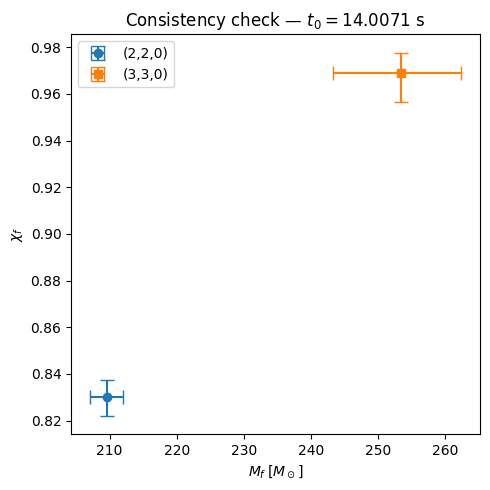

31398it [01:44, 301.03it/s, batch: 5 | bound: 6 | nc: 1 | ncall: 820570 | eff(%):  3.764 | loglstar: -1149.732 < -1142.125 < -1143.775 | logz: -1181.907 +/-  0.194 | stop:  0.747]       


Swapped f1 ↔ f2

t0 = 14.0071 s
220: f=93.6 Hz  chi=0.834  M=210.5 Msun
330: f=153.2 Hz  chi=0.968  M=254.6 Msun


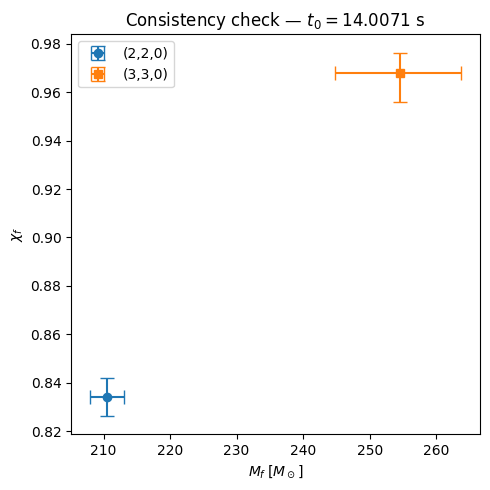

28595it [01:38, 488.26it/s, batch: 3 | bound: 1 | nc: 1 | ncall: 751783 | eff(%):  3.735 | loglstar: -1148.547 < -1147.491 < -1147.983 | logz: -1187.526 +/-  0.233 | stop:  1.431]      

In [ ]:
def consistency_check(t0_test):
    """Re-run the full pipeline for a given t0 and plot the (M, chi) consistency check."""
    import dynesty
    from dynesty import utils as dyfunc

    t_ring_test = t_on[t_on > t0_test]
    d_ring_test = d_on[t_on > t0_test]

    def _lnL(theta):
        A1, phi1, f1, tau1, A2, phi2, f2, tau2 = theta
        model = (A1 * np.cos(2*np.pi*f1*(t_ring_test - t0_test) + phi1) * np.exp(-(t_ring_test - t0_test)/tau1) +
                 A2 * np.cos(2*np.pi*f2*(t_ring_test - t0_test) + phi2) * np.exp(-(t_ring_test - t0_test)/tau2))
        return -0.5 * np.sum((d_ring_test - model)**2 / off_std**2)

    samp = dynesty.DynamicNestedSampler(_lnL, prior_transform, ndim=8, bound='multi', sample='rwalk')
    samp.run_nested(print_progress=True)

    weights = np.exp(samp.results.logwt - samp.results.logz[-1])
    s = dyfunc.resample_equal(samp.results.samples, weights)

    lo, med, hi = np.percentile(s, [16, 50, 84], axis=0)
    f1_m, f2_m       = med[2], med[6]
    f1_l, f2_l       = lo[2],  lo[6]
    f1_h, f2_h       = hi[2],  hi[6]
    tau1_m, tau2_m   = med[3], med[7]
    tau1_l, tau2_l   = lo[3],  lo[7]
    tau1_h, tau2_h   = hi[3],  hi[7]

    # Ensure f1 < f2 so f1/tau1 = 220 mode, f2/tau2 = 330 mode
    if f1_m > f2_m:
        f1_m, f2_m   = f2_m,   f1_m
        f1_l, f2_l   = f2_l,   f1_l
        f1_h, f2_h   = f2_h,   f1_h
        tau1_m, tau2_m = tau2_m, tau1_m
        tau1_l, tau2_l = tau2_l, tau1_l
        tau1_h, tau2_h = tau2_h, tau1_h
        print("Swapped f1 ↔ f2")

    r220 = omega_220.real / np.abs(omega_220.imag)
    r330 = omega_330.real / np.abs(omega_330.imag)

    chi_m_220 = np.interp(2*np.pi*f1_m*tau1_m, r220, chi_values)
    chi_l_220 = np.interp(2*np.pi*f1_l*tau1_l, r220, chi_values)
    chi_h_220 = np.interp(2*np.pi*f1_h*tau1_h, r220, chi_values)

    chi_m_330 = np.interp(2*np.pi*f2_m*tau2_m, r330, chi_values)
    chi_l_330 = np.interp(2*np.pi*f2_l*tau2_l, r330, chi_values)
    chi_h_330 = np.interp(2*np.pi*f2_h*tau2_h, r330, chi_values)

    wh_m_220, _, _ = mode_220(chi_m_220)
    wh_l_220, _, _ = mode_220(chi_l_220)
    wh_h_220, _, _ = mode_220(chi_h_220)
    M_m_220 = convert_to_Msun(wh_m_220.real / (2*np.pi*f1_m))
    M_l_220 = convert_to_Msun(wh_l_220.real / (2*np.pi*f1_h))
    M_h_220 = convert_to_Msun(wh_h_220.real / (2*np.pi*f1_l))

    wh_m_330, _, _ = mode_330(chi_m_330)
    wh_l_330, _, _ = mode_330(chi_l_330)
    wh_h_330, _, _ = mode_330(chi_h_330)
    M_m_330 = convert_to_Msun(wh_m_330.real / (2*np.pi*f2_m))
    M_l_330 = convert_to_Msun(wh_l_330.real / (2*np.pi*f2_h))
    M_h_330 = convert_to_Msun(wh_h_330.real / (2*np.pi*f2_l))

    print(f"\nt0 = {t0_test:.4f} s")
    print(f"220: f={f1_m:.1f} Hz  chi={chi_m_220:.3f}  M={M_m_220:.1f} Msun")
    print(f"330: f={f2_m:.1f} Hz  chi={chi_m_330:.3f}  M={M_m_330:.1f} Msun")

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_xlabel(r"$M_f \; [M_\odot]$")
    ax.set_ylabel(r"$\chi_f$")
    ax.set_title(rf"Consistency check — $t_0 = {t0_test:.4f}$ s")
    ax.errorbar(M_m_220, chi_m_220,
                xerr=[[M_m_220 - M_l_220], [M_h_220 - M_m_220]],
                yerr=[[chi_m_220 - chi_l_220], [chi_h_220 - chi_m_220]],
                fmt='o', capsize=5, label='(2,2,0)')
    ax.errorbar(M_m_330, chi_m_330,
                xerr=[[M_m_330 - M_l_330], [M_h_330 - M_m_330]],
                yerr=[[chi_m_330 - chi_l_330], [chi_h_330 - chi_m_330]],
                fmt='s', capsize=5, label='(3,3,0)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return s


# --- call it here, try different t0 values ---
t0_vals = np.linspace(t0-0.5, t0+0.5, 10)
for t0_val in t0_vals:
    sampe = consistency_check(t0)

## Q9: Why a good place to test GR?
- BHs and GWs are the extreme limit of the theory: deviations would be strongest here.